# CS301-002 Project Milestone 2 - Group 12: Happiness vs. Cost of Living
### Group Members:
* James Cayetano - jtc62@njit.edu
* Brandon Zhou - bz33@njit.edu
* John Kim - jyk26@njit.edu
* Aran Kashani - awk34@njit.edu

### Data Sources:
Dataset 1: [City Happiness Index - 2024 | Kaggle](https://www.kaggle.com/datasets/emirhanai/city-happiness-index-2024)
- This dataset contains over 520 cities from across the world with features related to quality of life such as noise levels, the level of traffic density, air quality index, and healthcare quality.

Dataset 2: [Global Cost of Living | Kaggle](https://www.kaggle.com/datasets/mvieira101/global-cost-of-living)
- This dataset contains around 5000 cities from across the world with features related to said cities’ cost of living such as the cost for different types of meals, groceries, the prices of gas, property value, and salary rate.

# 1. Exploratory Data Analysis
The goal of this exploratory data analysis is to identify the distribution of the data, find any multicollinearity, and observe how features may impact the target.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

happiness = pd.read_csv('content/train.csv')
cost = pd.read_csv('content/cost-of-living_v2.csv')

happiness = happiness.drop('Cost_of_Living_Index', axis=1) # We will be calculating our own cost of living index using the cost dataset.

## City Happiness Index EDA

In [2]:
happiness.head(5)

,City,Month,Year,Decibel_Level,Traffic_Density,Green_Space_Area,Air_Quality_Index,Happiness_Score,Healthcare_Index
0,New York,January,2024,70,High,35,40,6.5,80
1,Los Angeles,January,2024,65,Medium,40,50,6.8,75
2,Chicago,January,2024,60,Medium,30,55,7.0,70
3,London,January,2024,55,High,50,60,7.2,85
4,Paris,January,2024,60,High,45,65,6.9,80


In [3]:
happiness.describe()

,Year,Decibel_Level,Green_Space_Area,Air_Quality_Index,Happiness_Score,Healthcare_Index
count,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,2026.082569,56.779817,1085.366972,38.036697,-44.865505,93.086239
std,1.652363,6.856402,756.993165,36.300656,42.407240,10.550034
min,2024.000000,50.000000,5.000000,5.000000,-122.900000,35.000000
25%,2025.000000,55.000000,385.000000,25.000000,-82.100000,95.000000
50%,2026.000000,55.000000,1065.000000,30.000000,-41.300000,96.000000
75%,2027.000000,60.000000,1745.000000,35.000000,-0.500000,97.000000
max,2029.000000,90.000000,2425.000000,245.000000,8.600000,99.000000


There seems to be some anomolous data in the Happiness score column, which should only have values from 1 to 10, according to the data sheet.

Text(0.5, 1.0, 'Heatmap of data where Happiness_Score >= 1')

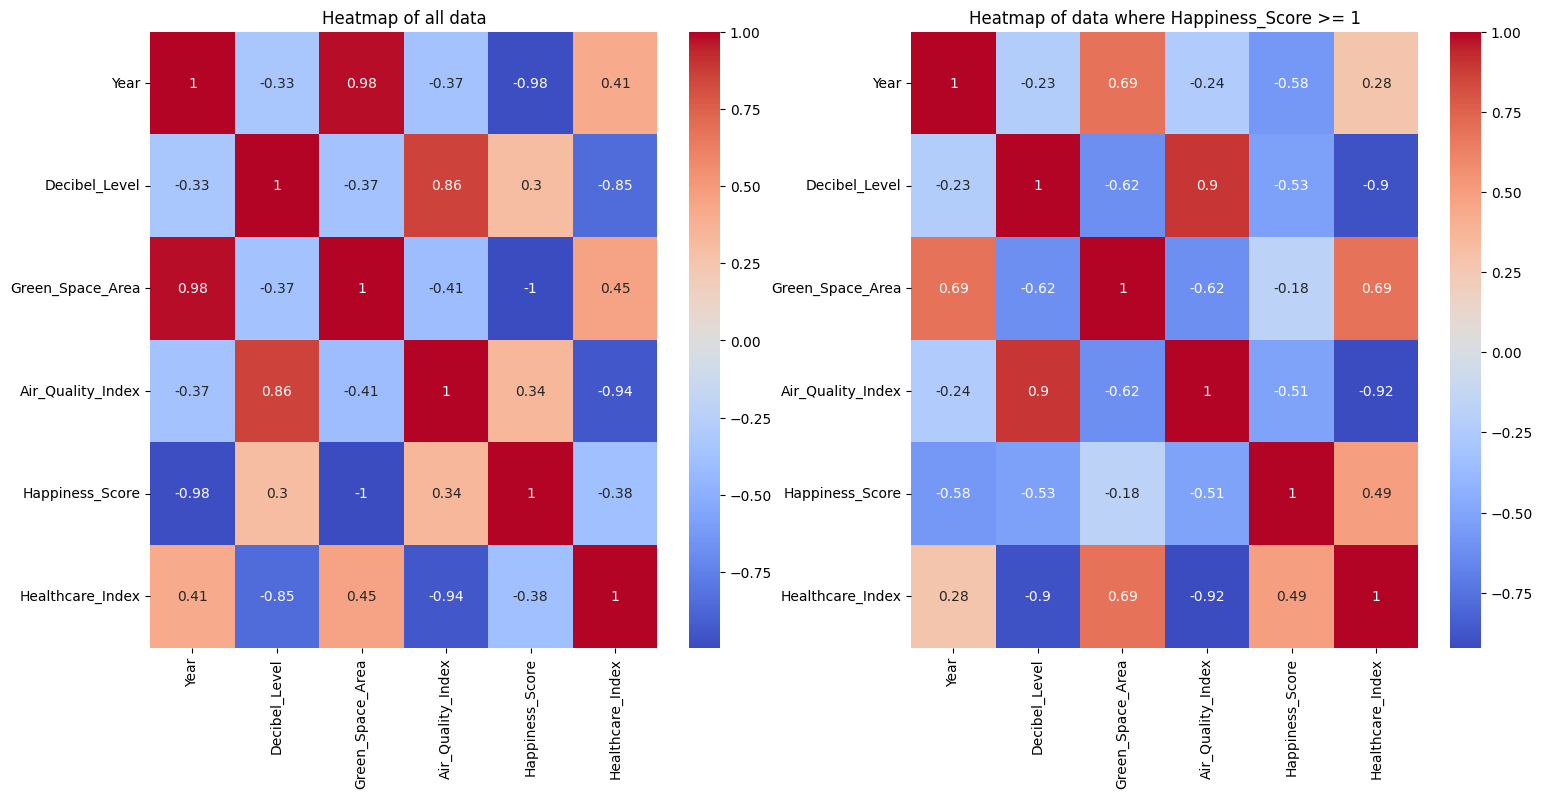

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(18,8))
cols = ['Year', 'Decibel_Level', 'Green_Space_Area', 'Air_Quality_Index', 'Happiness_Score', 'Healthcare_Index']

sns.heatmap(happiness[cols].corr(), cmap="coolwarm", annot=True, ax=ax[0])
sns.heatmap(happiness[cols][happiness['Happiness_Score'] >= 1].corr(), cmap="coolwarm", annot=True, ax=ax[1])

ax[0].set_title('Heatmap of all data')
ax[1].set_title('Heatmap of data where Happiness_Score >= 1')

From the heatmaps, the anomalous happiness scores appear to distort the data. In the full dataset, `Year` has a near-perfect positive correlation with `Green_Space_Area` which is suspicious because it is showing that nearly every city in the dataset has been gaining green space in a perfect linear manner. `Year` also had a near-perfect negative correlation with the Happiness_Score, suggesting that the data may be affected by a poor transformation or artificially generated. Moreover, the green space and happiness score have a nearly perfect negative linear correlation, indicating that happiness correlates negatively with green space, but this relationship is questionable as it is expected that more green space would have a positive or weak correlation with happiness.

After removing the rows with invalid happiness scores, several relationships between features become less extreme and more reasonable. For example , `Happiness_Score` becomes positively correlated with `Healthcare_Index` and negatively correlated with `Decibel_Level` and `Air_Quality_Index`, which is more reasonable. The cleaned data also still shows some other strong relationships such as the negative correlations between `Decibel_Level` and `Healthcare_Index`, and bbetween `Air_Quality_Index` and `Healthcare_Index`.

The `Air_Quality_Index` demonstrated a strong correlation with `Decibel_Level`; one reason that supports this is that cities may be louder due to a high amount of vehicular traffic, which also degrades the air quality.

The project will continue with the filtered data, which has 131 instances compared to the original 545. Although this is a significantly smaller sample size, this data is much more reasonable because it removes the invalid happiness scores that distorted the correlation between features.

In [5]:
happiness = happiness[happiness['Happiness_Score'] >= 1] # Use only data with valid happiness scores

In [6]:
happiness.isna().sum()

City                 0
Month                0
Year                 0
Decibel_Level        0
Traffic_Density      0
Green_Space_Area     0
Air_Quality_Index    0
Happiness_Score      0
Healthcare_Index     0
dtype: int64

The happiness dataset has no missing values, which is good.

Because this project does not focus on time trends, the year and month columns can be dropped.

In [7]:
happiness = happiness.drop(['Year', 'Month'], axis=1)

In [8]:
happiness.dtypes

City                     str
Decibel_Level          int64
Traffic_Density          str
Green_Space_Area       int64
Air_Quality_Index      int64
Happiness_Score      float64
Healthcare_Index       int64
dtype: object

The following features are numerical:
* Decibel_Level
* Green_Space_Area
* Air_Quality_Index
* Happiness_Score
* Cost_of_Living_Index
* Healthcare_Index

The following features are categorical:
* City (nominal)
* Traffic Density (ordinal)

In [9]:
happiness.head(5)

,City,Decibel_Level,Traffic_Density,Green_Space_Area,Air_Quality_Index,Happiness_Score,Healthcare_Index
0,New York,70,High,35,40,6.5,80
1,Los Angeles,65,Medium,40,50,6.8,75
2,Chicago,60,Medium,30,55,7.0,70
3,London,55,High,50,60,7.2,85
4,Paris,60,High,45,65,6.9,80


In [10]:
happiness.describe()

,Decibel_Level,Green_Space_Area,Air_Quality_Index,Happiness_Score,Healthcare_Index
count,131.000000,131.000000,131.000000,131.000000,131.000000
mean,62.442748,114.732824,71.412214,5.971756,82.282443
std,10.694470,104.984088,62.745747,2.021472,17.519780
min,50.000000,5.000000,5.000000,1.000000,35.000000
25%,55.000000,30.000000,30.000000,4.500000,70.000000
50%,60.000000,70.000000,35.000000,6.200000,90.000000
75%,70.000000,192.500000,100.000000,7.800000,96.000000
max,90.000000,355.000000,245.000000,8.600000,99.000000


### Univariate Exploration

Text(0.5, 0.905, 'Histograms of each feature in the first dataset')

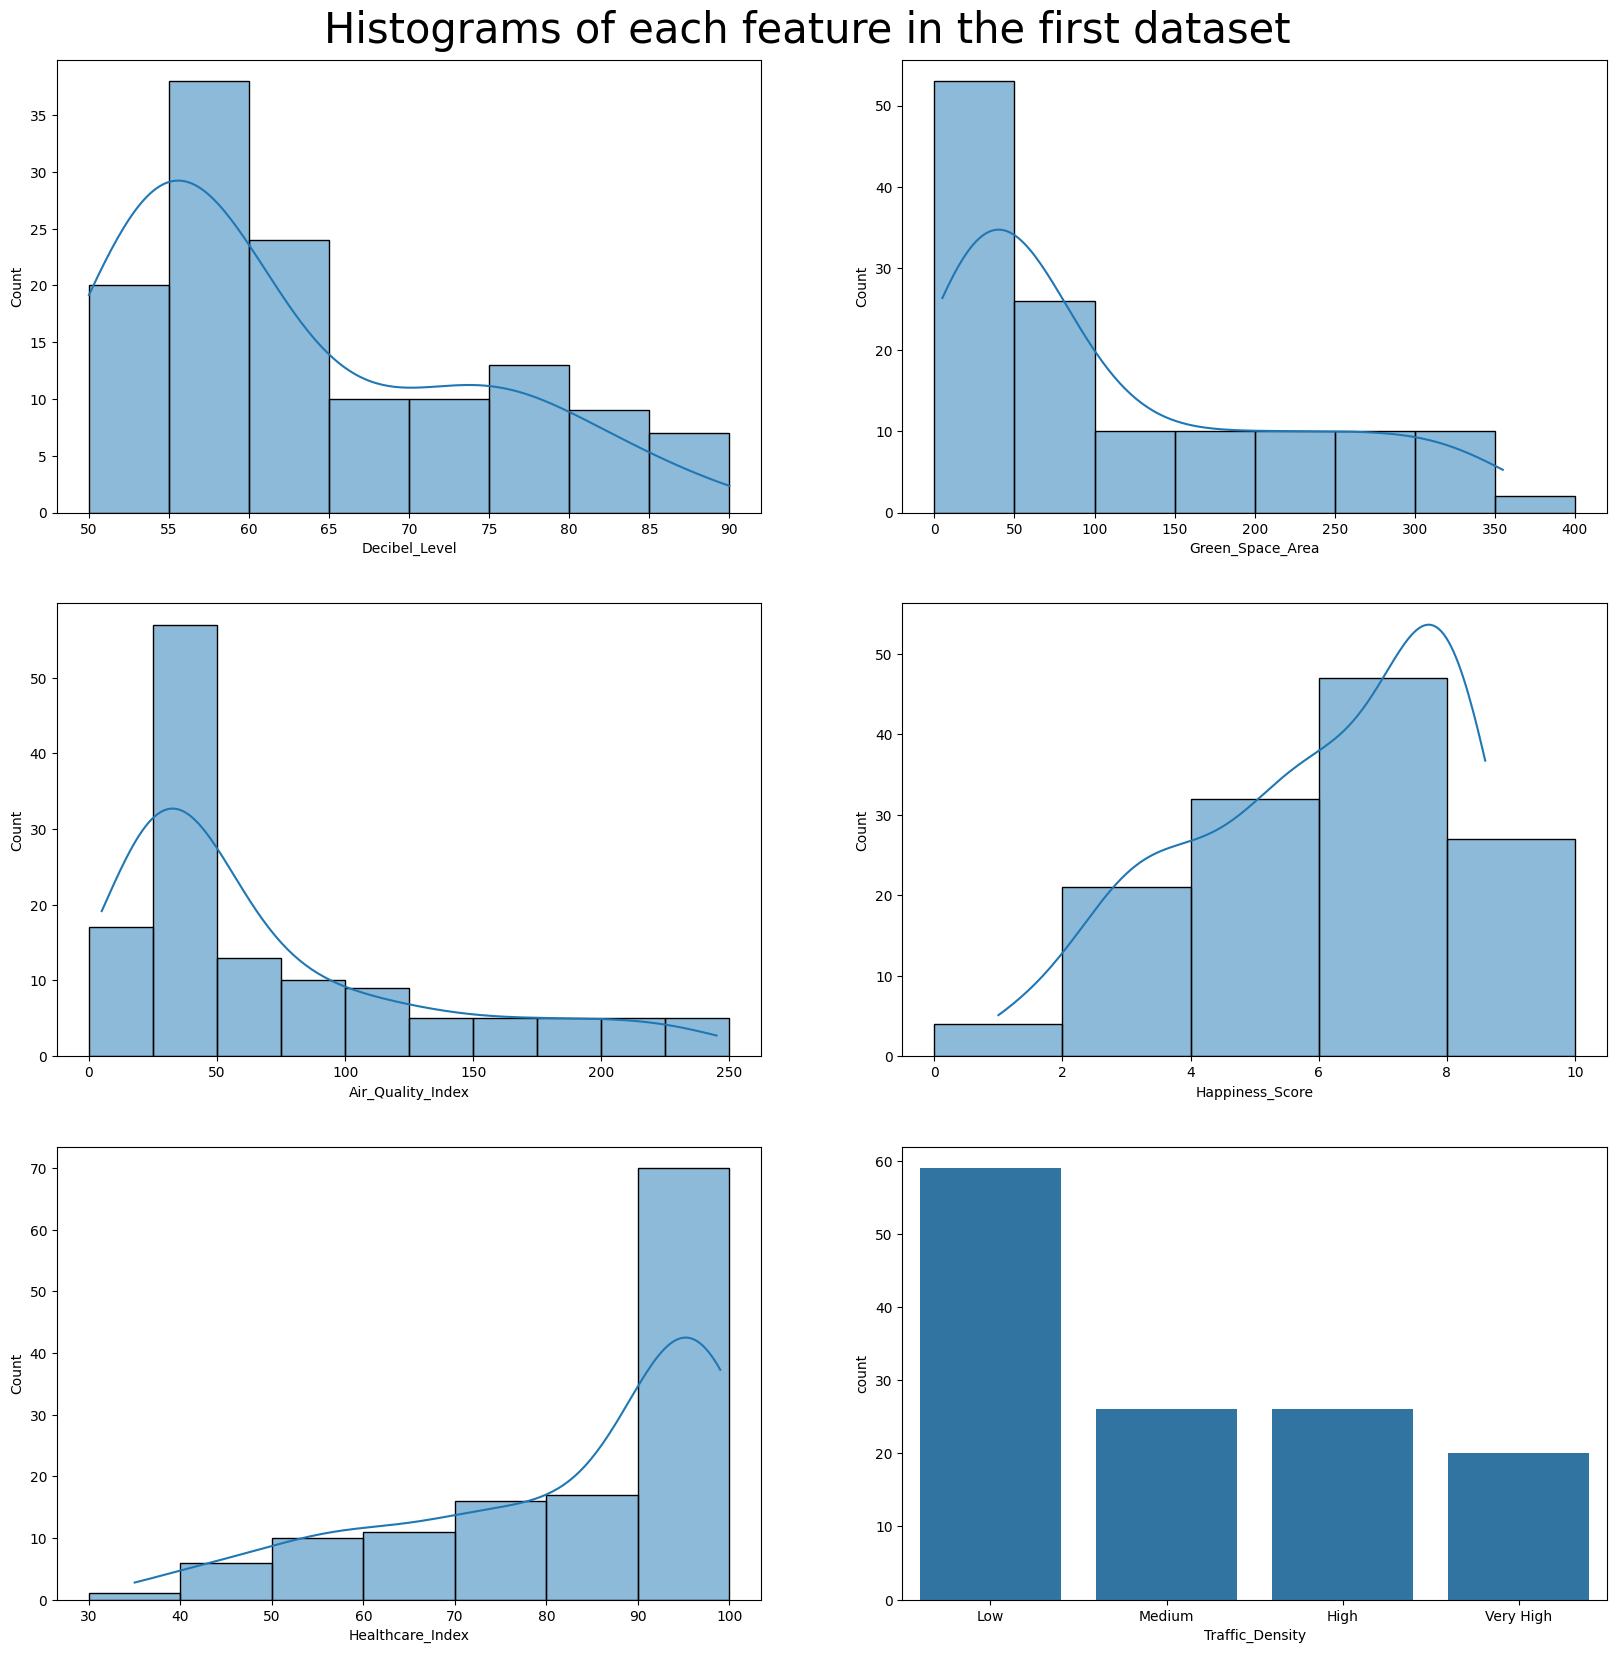

In [11]:
# Plot distributions of each feature and the target
happiness_numeric = {
    'Decibel_Level':np.arange(50, 95, 5),
    'Green_Space_Area':np.arange(0, 450, 50),
    'Air_Quality_Index':np.arange(0, 275, 25),
    'Happiness_Score':np.arange(0, 12, 2),
    'Healthcare_Index':np.arange(30, 110, 10)
}

fig, ax = plt.subplots(3, 2, figsize=(20, 20))
for idx, col in enumerate(happiness_numeric.keys()):
    sns.histplot(happiness[col], ax=ax[idx//2][idx % 2], kde=True, bins=happiness_numeric[col])
sns.countplot(data=happiness, x='Traffic_Density', order=['Low', 'Medium', 'High', 'Very High'], ax=ax[2][1]) 
fig.suptitle('Histograms of each feature in the first dataset', y=0.905, fontsize=30)

#### Observations

Overall, the data is not normally distributed. Many numerical features are heavily skewed with long tails, indicating that there are outliers present within the data.

**Decibel_Level**: Skewed Right

Most of the data is within the 50-65 range. There is a right tail with outliers extending up around 90, indicating that most cities experienced a moderate noise level, with some experiencing much higher noise.

**Green_Space_Area**: Skewed Right

The distribution shows that there were a large number of observations with very little green space, followed by a relatively uniform distribution of cities with little to high green space.

**Air_Quality_Index**: Skewed Right

A large portion cities had a air quality index [categorized as good](https://www.epa.gov/wildfire-smoke-course/communicating-air-quality-conditions-air-quality-index). The other cities cities reported poorer air quality in the "moderate" and "unhealthy for sensitive groups" categories, growing fewer in number as the air quality index increased.

**Happiness_Score**: Skewed Left

Most happiness scores are in a moderate to high range between 5-9, with a few low scores below 3.

**Healtcare_Index**: Skewed left

The majority of cities reported a high healthcare index between 85 and 100.

**Traffic_Density**: Skewed left

Many cities reported a low traffic density. The others report medium, high, and very high traffic density in a somewhat uniform manner.

## Global Cost of Living Data EDA

This dataset contains information about the cost of various things such as food, drinks, groceries, vehicles, rent, etc. in cities around the world. Costs are reported in USD, and the column descriptions can be found at the [data source](https://www.kaggle.com/datasets/mvieira101/global-cost-of-living).

The columns `x54` (average monthly net salary) and `x55` (mortgage interest rate) will not be used in this analysis as they do not reflect cost-of-living prices as clearly as the other features.

In [12]:
cost = cost.drop(['x54', 'x55'], axis=1)

In [13]:
cost.head(5)

,city,country,x1,x2,x3,x4,x5,x6,x7,x8,...,x45,x46,x47,x48,x49,x50,x51,x52,x53,data_quality
0,Seoul,South Korea,7.68,53.78,6.15,3.07,4.99,3.93,1.48,0.79,...,46.36,70.81,110.36,742.54,557.52,2669.12,1731.08,22067.70,10971.90,1
1,Shanghai,China,5.69,39.86,5.69,1.14,4.27,3.98,0.53,0.33,...,34.92,88.21,123.51,1091.93,569.88,2952.70,1561.59,17746.11,9416.35,1
2,Guangzhou,China,4.13,28.47,4.98,0.85,1.71,3.54,0.44,0.33,...,33.83,66.73,43.89,533.28,317.45,1242.24,688.05,12892.82,5427.45,1
3,Mumbai,India,3.68,18.42,3.68,2.46,4.30,2.48,0.48,0.19,...,27.75,49.87,41.17,522.40,294.05,1411.12,699.80,6092.45,2777.51,1
4,Delhi,India,4.91,22.11,4.30,1.84,3.68,1.77,0.49,0.19,...,33.44,49.99,36.50,229.84,135.31,601.02,329.15,2506.73,1036.74,1


In [14]:
cost.describe()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x45,x46,x47,x48,x49,x50,x51,x52,x53,data_quality
count,4528.000000,4505.000000,4622.000000,4460.000000,4516.000000,4612.000000,4511.000000,4640.000000,4578.000000,4543.000000,...,4339.000000,4453.000000,4403.000000,3593.000000,3525.000000,3476.000000,3444.000000,2729.000000,2653.000000,4956.000000
mean,10.346705,43.357811,6.929697,3.379774,3.942465,2.754952,1.523873,1.119804,1.148554,1.612855,...,35.039650,76.998309,85.976357,711.574943,560.159957,1253.982914,974.082854,3235.270854,2341.933102,0.186239
std,7.157058,25.528312,2.704435,2.105957,2.100146,1.358821,0.907025,0.755257,0.517186,1.089164,...,15.173614,33.252260,40.434524,648.869301,527.492342,1219.395297,921.331271,6258.792897,3570.623878,0.389339
min,0.450000,3.250000,1.080000,0.330000,0.310000,0.220000,0.110000,0.070000,0.260000,0.050000,...,0.000000,8.030000,7.600000,21.700000,12.200000,61.510000,27.120000,111.010000,49.240000,0.000000
25%,4.310000,22.440000,4.980000,1.600000,2.200000,1.580000,0.770000,0.480000,0.830000,0.780000,...,26.340000,61.900000,58.430000,256.240000,171.050000,465.200000,325.710000,1120.110000,790.310000,0.000000
50%,9.600000,40.000000,6.990000,3.000000,3.690000,2.630000,1.480000,1.050000,1.045000,1.320000,...,33.130000,75.000000,84.260000,526.870000,403.940000,921.075000,712.830000,2107.490000,1580.620000,0.000000
75%,15.000000,60.000000,8.500000,5.000000,5.270000,3.770000,2.110000,1.580000,1.320000,2.200000,...,41.510000,88.670000,106.770000,992.610000,790.310000,1710.225000,1369.870000,3843.380000,2798.250000,0.000000
max,57.140000,213.690000,22.130000,20.600000,17.500000,10.000000,8.000000,5.850000,6.810000,8.820000,...,219.380000,923.120000,542.740000,12608.830000,8989.370000,27397.380000,17868.180000,240963.670000,80321.220000,1.000000


In [15]:
cost.isna().sum()

city               0
country            0
x1               428
x2               451
x3               334
x4               496
x5               440
x6               344
x7               445
x8               316
x9               378
x10              413
x11              343
x12              507
x13              478
x14              558
x15              566
x16              372
x17              381
x18              441
x19              469
x20              437
x21              433
x22              501
x23              388
x24              462
x25              721
x26              655
x27              490
x28             1506
x29             2166
x30              873
x31             1022
x32             1396
x33              588
x34             1058
x35              995
x36              488
x37             1201
x38              349
x39             1375
x40             2400
x41              475
x42             1132
x43             1681
x44              479
x45              617
x46          

Generally, if a row has multiple N/A values, the value of data_quality is 0:

In [16]:
print(cost[cost['data_quality'] == 0].shape)
cost[cost['data_quality'] == 0].head(5)

(4033, 56)


,city,country,x1,x2,x3,x4,x5,x6,x7,x8,...,x45,x46,x47,x48,x49,x50,x51,x52,x53,data_quality
9,Kinshasa,Congo,15.11,42.63,10.08,1.74,2.50,4.35,2.78,0.84,...,35.00,127.50,93.33,2000.00,725.00,4500.00,1160.00,6170.63,933.33,0
36,Baoding,China,NaN,14.24,3.99,NaN,NaN,2.85,0.47,NaN,...,35.59,99.65,284.71,NaN,NaN,NaN,NaN,1992.97,NaN,0
40,Nanyang,China,2.85,21.35,4.27,1.14,1.99,2.73,0.42,0.25,...,32.03,83.51,110.32,NaN,113.88,NaN,NaN,NaN,NaN,0
41,Shijiazhuang,China,3.20,19.22,4.98,0.78,1.42,3.54,0.41,0.28,...,35.59,78.30,49.82,213.53,128.12,427.06,284.71,2562.39,1850.61,0
43,Luanda,Angola,7.84,64.25,10.51,2.20,1.50,3.93,1.95,1.42,...,150.31,267.21,208.25,220.39,80.85,6880.05,346.62,5421.61,3448.79,0


In [17]:
# count the number of NaN values in each row
cost['missing_count'] = cost.isna().sum(axis=1)

Text(0.5, 0, 'Number of missing values')

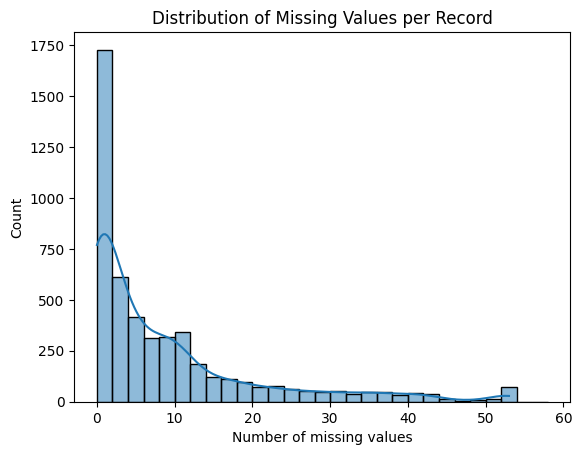

In [18]:
sns.histplot(cost['missing_count'], kde=True, bins=np.arange(0, 60, 2))
plt.title('Distribution of Missing Values per Record')
plt.xlabel('Number of missing values')

The distribution of missing values is right-skewed. Most cities have relatively few missing features, which means that a cost of living index can be computed from a mostly-complete set of variables. Cities with a large number of missing values can produce an unreliable cost of living index, so they should be avoided.

### Univariate Exploration
It is unreasonable to view the distribution of every single feature in this dataset, so we will first group them into the following categories:
* Food (subgroups: restaurant and grocery)
* Transportation (subgroups: public transit, taxis, fuel, vehicle purchase)
* Utilities
* Lifestyle (subgroups: discretionary goods, clothing, recreation)
* Housing
* Rent
* Childcare

For each subcategory, we will min-max scale its values then average them. Then, we can average the subcategories to get the value for the category. This is necessary because higher-cost items like meats would have more impact on the average than a lower-cost item such as rice. Additionally, some subcategories have more columns than others, which would cause them to have a higher impact the averages for the category.

If a category does not have a subcategory, its values will be min-max scaled and then averaged.

Once the category averages are computed, they will be transformed into a scale from 0 to 100.

In [19]:
from sklearn.preprocessing import MinMaxScaler

# food
restaurant = ['x1', 'x2', 'x3', 'x6', 'x7', 'x8']
grocery = ['x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23']

# transportation
public_transit = ['x28', 'x29']
taxi = ['x30', 'x31', 'x32']
fuel = ['x33']
vehicle = ['x34', 'x35']

# utilities
utilities = ['x36', 'x37', 'x38']

# lifestyle
discretionary = ['x4', 'x5', 'x24', 'x25', 'x26', 'x27']
clothing = ['x44', 'x45', 'x46', 'x47']
recreation = ['x39', 'x40', 'x41']

# housing
housing = ['x52', 'x53']

# rent
rent = ['x48', 'x49', 'x50', 'x51']

# childcare
childcare = ['x42', 'x43']

# scale values in each column
cols = ['x' + str(num) for num in range(1, 54)]
min_max_scaler = MinMaxScaler()
cost_scaled = pd.DataFrame(min_max_scaler.fit_transform(cost[cols]), columns=[col + '_scaled' for col in cols], index=cost.index)

# compute average of each subcategory/category without subcategories
subcategories = {'restaurant':restaurant, 'grocery':grocery, 'public_transit':public_transit, 'taxi':taxi, 'fuel':fuel, 'vehicle':vehicle, 'utilities':utilities, 'discretionary':discretionary, 'clothing':clothing, 'recreation':recreation, 'housing':housing, 'rent':rent, 'childcare':childcare}

for name, sc in subcategories.items():
    cols = [x + '_scaled' for x in sc]
    cost_scaled[name] = cost_scaled[cols].mean(axis=1)

cost_scaled.head(5)

# compute average of each category with subcategories
cost_scaled['food'] = cost_scaled[['restaurant', 'grocery']].mean(axis=1)
cost_scaled['transportation'] = cost_scaled[['public_transit', 'taxi', 'fuel', 'vehicle']].mean(axis=1)
cost_scaled['lifestyle'] = cost_scaled[['discretionary', 'clothing', 'recreation']].mean(axis=1)

# match category values to cities in the original data
cost_categorized = cost[['city', 'country', 'missing_count']].join(cost_scaled[['food', 'transportation', 'utilities', 'lifestyle', 'housing', 'rent', 'childcare']])

# calculate cost of living index by averaging categories:
cost_categorized['cost_of_living'] = cost_categorized[['food', 'transportation', 'utilities', 'lifestyle', 'housing', 'rent', 'childcare']].mean(axis=1)

# convert everything to a 0-100 scale:
for col in ['food', 'transportation', 'utilities', 'lifestyle', 'housing', 'rent', 'childcare', 'cost_of_living']:
    cost_categorized[col] = cost_categorized[col] * 100

cost_categorized.head(10)

,city,country,missing_count,food,transportation,utilities,lifestyle,housing,rent,childcare,cost_of_living
0,Seoul,South Korea,0,24.873153,19.014745,9.870838,18.234677,11.361649,7.722813,16.646369,15.389177
1,Shanghai,China,0,15.424009,14.186684,2.697611,16.301130,9.495580,8.473024,33.820082,14.342589
2,Guangzhou,China,0,11.768791,13.840352,2.227007,13.263838,6.003442,3.872122,22.860669,10.548032
3,Mumbai,India,0,7.346493,12.602594,1.450128,11.939487,2.941113,3.956262,3.668040,6.272016
4,Delhi,India,0,7.144550,12.247166,1.905750,10.524025,1.112438,1.672872,2.132988,5.248541
5,Dhaka,Bangladesh,0,7.093376,15.122932,1.246389,13.314416,0.534902,0.965396,1.745647,5.717580
6,Osaka,Japan,0,19.027896,22.748567,9.549476,19.489968,4.621825,5.197191,12.797443,13.347481
7,Jakarta,Indonesia,0,9.788854,11.058518,5.970578,13.324009,1.265895,3.539260,8.029561,7.568097
8,Shenzhen,China,0,13.806447,14.243022,3.019920,14.733909,8.702081,5.287832,23.298246,11.870208
9,Kinshasa,Congo,0,27.708536,18.308045,25.913011,16.368863,1.808636,11.560927,23.616585,17.897800


Text(0.5, 1.0, 'Heatmap of correlation between cost of living categories')

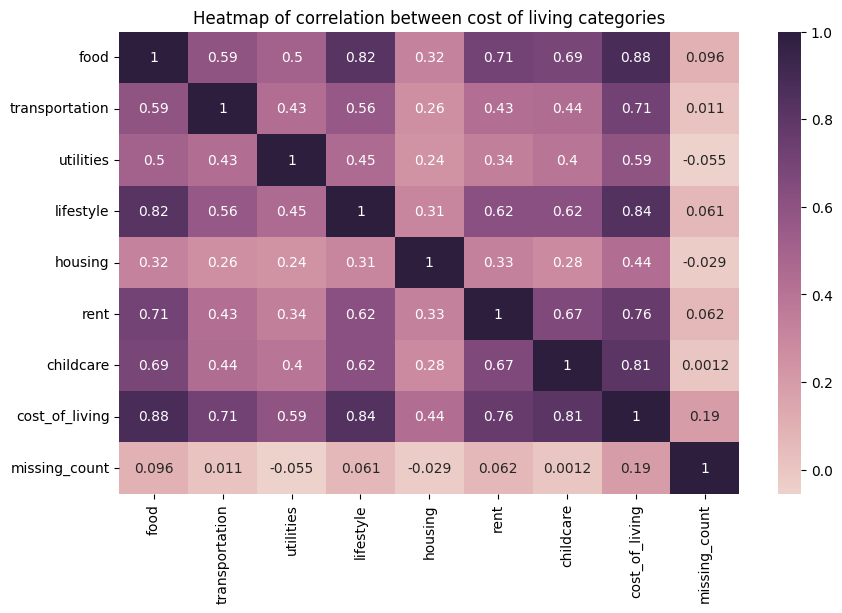

In [20]:
plt.figure(figsize=(10, 6))
sns.heatmap(cost_categorized[['food', 'transportation', 'utilities', 'lifestyle', 'housing', 'rent', 'childcare', 'cost_of_living', 'missing_count']].corr(), cmap=sns.cubehelix_palette(as_cmap=True), annot=True)
plt.title('Heatmap of correlation between cost of living categories')

All costs between categories have a positive correlation; this is expected as cities that are expensive in one category are generally expensive in other categories as well.

The categories in order of strongest to weakest correlation to `cost_of_living` are `food`, `lifestytle`, `childcare`, `rent`, `transportation`, `utilities`, and `housing`.

The housing category had the weakest correlation to the other categories; this indicates that housing prices are influenced by factors outside of regular living expenses.

Food and lifestyle are also strongly correlated, indicating that cities with high food costs also tend to have high costs for lifestyle purchases such as fitness, entertainment, clothing, and discretionary items.

It is important to note that there is a weak positive correlation between the number of missing values and the cost of living index. This indicates that cities with large amounts of missing values are may reflect a higher cost of living than what is actually true, so these should not be used.

Text(0.5, 0.905, 'Histograms of Each Cost-of-Living Category')

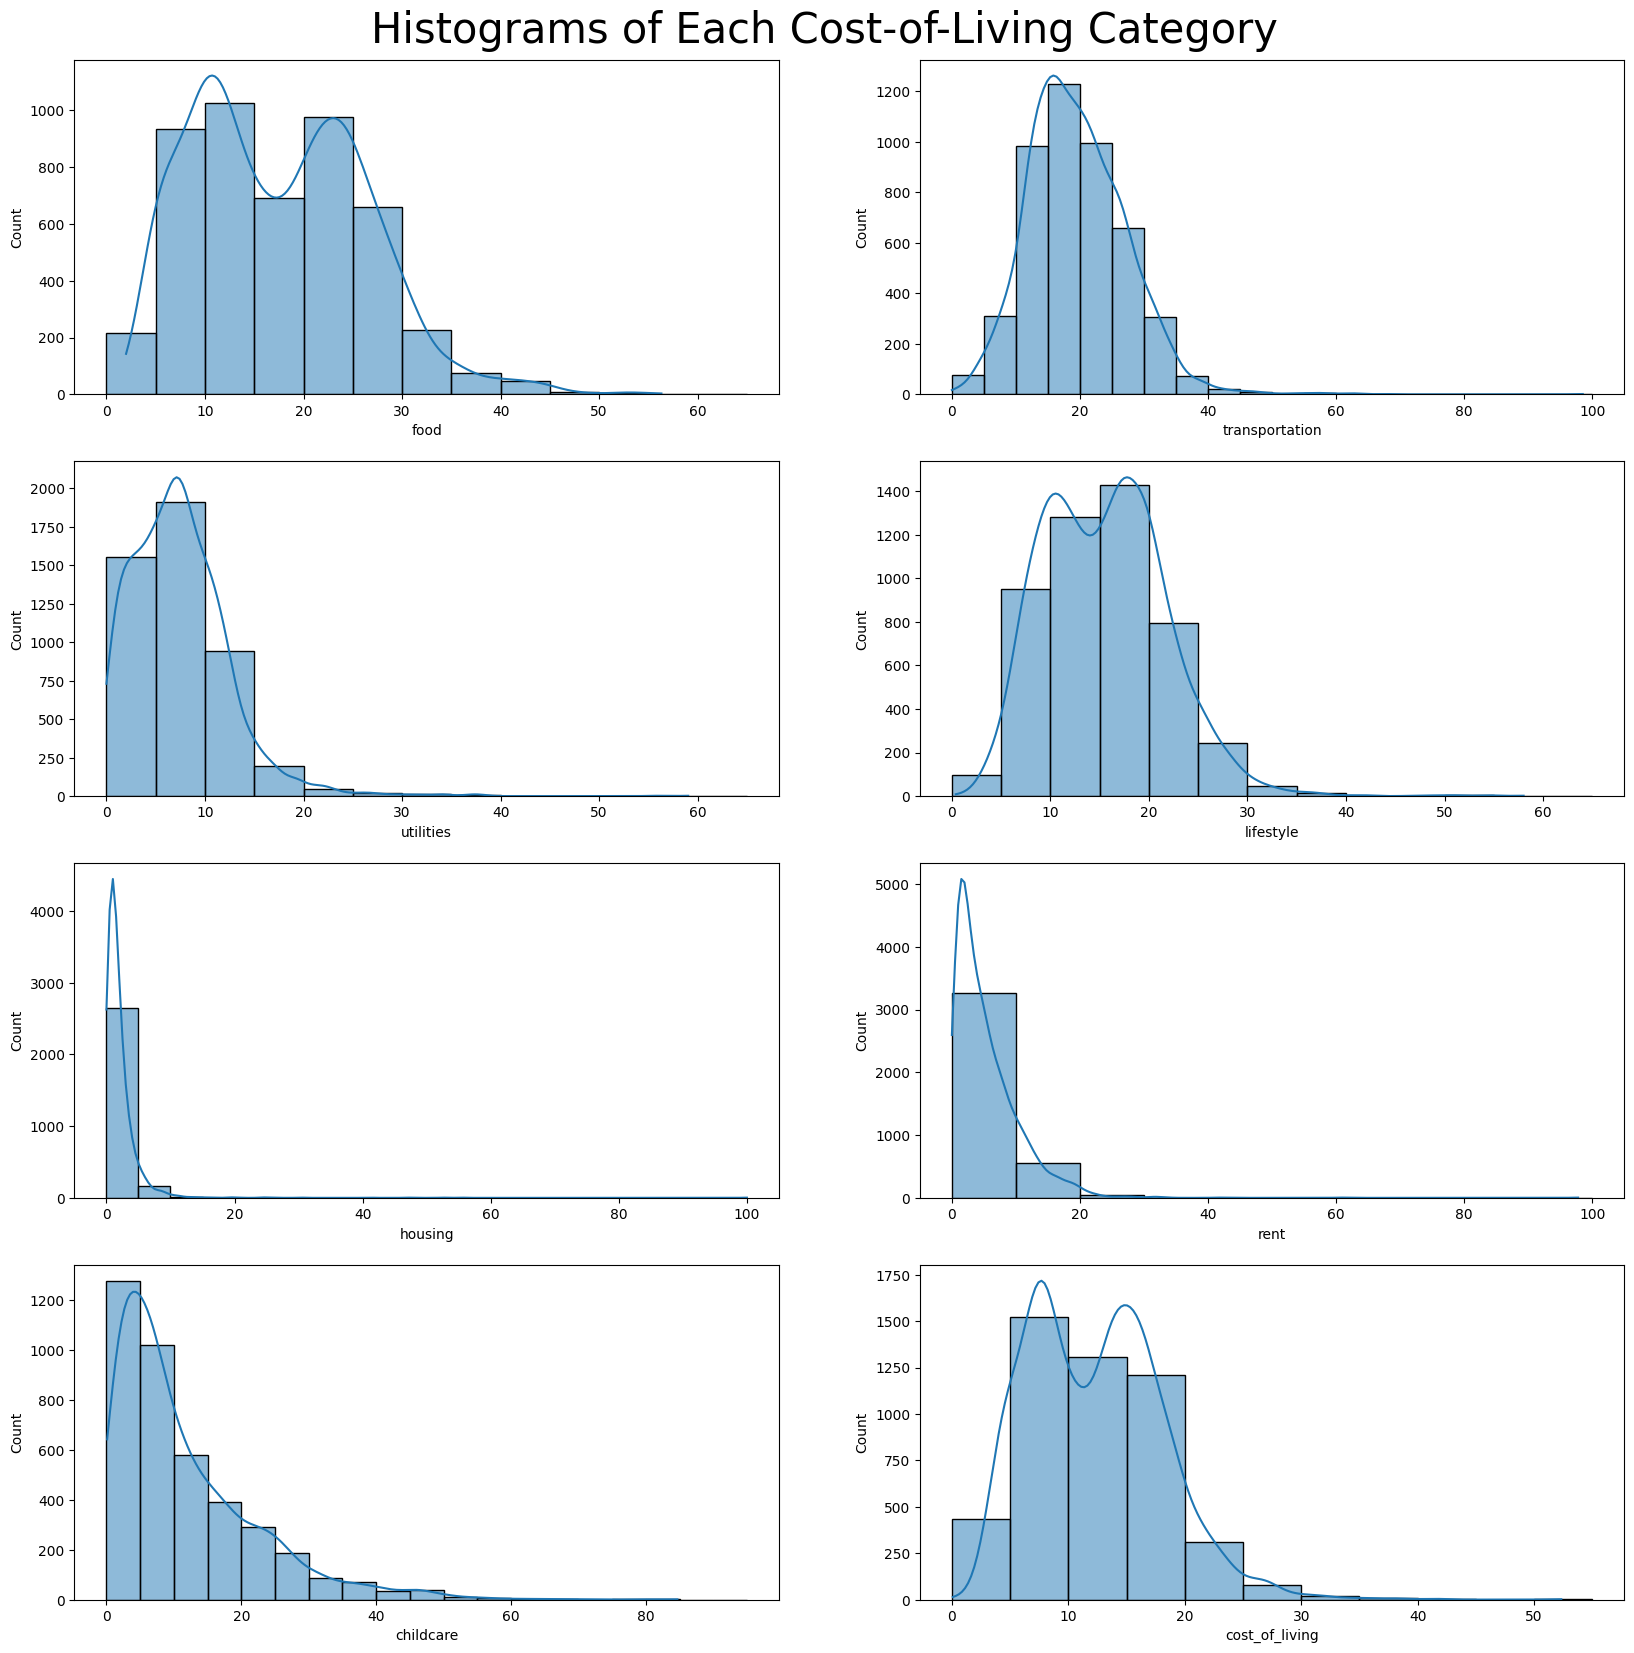

In [21]:
# Plot distributions of each category
categories = {
    'food': np.arange(0, 70, 5),
    'transportation': np.arange(0, 105, 5),
    'utilities': np.arange(0, 70, 5),
    'lifestyle': np.arange(0, 70, 5),
    'housing': np.arange(0, 105, 5),
    'rent': np.arange(0, 105, 10),
    'childcare': np.arange(0, 100, 5),
    'cost_of_living': np.arange(0, 60, 5)
}

fig, ax = plt.subplots(4, 2, figsize=(20, 20))
for idx, col in enumerate(categories.keys()):
    sns.histplot(cost_categorized[col], ax=ax[idx//2][idx % 2], kde=True, bins=categories[col])
fig.suptitle('Histograms of Each Cost-of-Living Category', y=0.905, fontsize=30)

#### Observations

The categories are right-skewed, indicating that cities generally have low to moderate costs of living, with a few outlier cities that are more expensive

**food**: Bimodal; Skewed right

The distribution of food costs appears bimodal, meaning that the data may contain two groups of cities: one with lower food cost and one with higher food cost. There is also a right tail with a few cities having unusually high food costs.

**transportation**: Slightly skewed right

The transportation distribution is skewed slightly right with a few cities reaching extreme transportation costs, either from vehicle, taxi, or gas prices.

**utilities**: Skewed right

Most cities appear to have a utilities cost of less than 15, with some cities having extremely high values of up to 50. This shows that most cities have a relatively low utility index.

**lifestyle**: Bimodal; Skewed right

The KDE line indicates that lifestyle is somewhat bimodal, with visible clusters around lower and higher lifestyle index, indicating that there could be differences between low-cost cities and major cities where costs for recreation, clothing, and discretionary goods can be more expensive.

**housing**: Skewed right

Housing has an extreme right-skew. Most cities are on the low end of costs, but a small number have very high housing purchase costs. This makes sense because housing purchase prices can vary dramatically depending on the city.

**rent**: Skewed right

Like housing, rent is also extremely right-skewed. Most cities have lower rent costs, but a small number have very high rent costs.

**childcare**: Skewed right

Childcare is also skewed right, but not as severely as housing and rent. Most cities appear to have moderate to high housing costs

**cost_of_living**: Bimodal; Skewed right

As expected, the cost of living index is skewed right because it is an aggregate of the other measures. It appears to be bimodal, with some cities having much higher overall cost-of-living. It may have inherited the bimodalness from the food and lifestyle categories as those have the highest correlation with the cost of living.

In [22]:
cost_categorized[['country'] + list(categories.keys())].groupby('country').mean().sort_values(by='cost_of_living')

,food,transportation,utilities,lifestyle,housing,rent,childcare,cost_of_living
country,,,,,,,,
Egypt,4.349378,5.628697,1.038887,7.012291,0.208220,0.573056,1.626758,3.023126
Pakistan,3.939400,8.314944,1.855193,5.813268,0.379639,0.398512,0.682541,3.419992
Libya,5.130267,5.449247,1.648597,5.795724,6.612062,0.844396,1.042065,3.675408
Sri Lanka,5.139699,9.904425,0.954238,5.260293,0.691150,0.455339,0.667155,3.821310
Tunisia,4.135434,8.817220,2.408745,6.829674,0.432164,0.773749,1.849226,3.845345
...,...,...,...,...,...,...,...,...
Nauru,39.633996,32.425068,25.057515,15.266210,NaN,16.057224,NaN,25.688002
Turkmenistan,39.485285,7.523524,22.808981,42.038543,2.126266,4.033672,12.270056,26.794222
Switzerland,42.507320,37.688533,13.647246,29.983701,7.904471,11.821335,44.068172,27.321980


As indicated by the correlation structure of the data, the countries whos cities averaged the highest cost of living also tend to have average higher costs in the individual categories. This makes sense because the cost of living index is the average of the individual category costs.

## Merged Data EDA

In [23]:
# merge with happiness data for bivariate exploration with the target
cost_categorized = cost_categorized.rename(columns={'city':'City'})
merged = pd.merge(happiness, cost_categorized, on='City')

# There are some cities in different countries that share a name. Since the country isn't be used in the statistcal analysis/ML, we can arbitrarily drop duplicates.
merged = merged.drop([4, 25, 93, 63, 44, 82, 84]) # 4             London                Canada
                                                  # 25         Barcelona             Venezuela
                                                  # 93         Cambridge                Canada
                                                  # 63           Colombo                Brazil
                                                  # 44          Santiago                Panama
                                                  # 82          Hamilton               Bermuda
                                                  # 84          Hamilton             Australia

In [24]:
merged.sort_values(by='missing_count', ascending=False).head(4)

,City,Decibel_Level,Traffic_Density,Green_Space_Area,Air_Quality_Index,Happiness_Score,Healthcare_Index,country,missing_count,food,transportation,utilities,lifestyle,housing,rent,childcare,cost_of_living
95,Waihi,55,Low,205,20,7.5,98,New Zealand,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79,Queenstown,55,Low,95,15,8.4,96,Australia,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92,Te Awamutu,50,Low,180,25,8.1,97,New Zealand,13,22.989431,24.541281,2.833868,17.967873,0.609817,1.933125,NaN,11.812566
52,San Juan,75,High,25,145,6.0,70,Argentina,4,10.123765,12.123926,4.477555,13.798094,NaN,0.983588,1.428167,7.155849


In [25]:
merged = merged.drop([95, 79, 92])

Text(0.5, 1.0, 'Correlation Heatmap of the Merged Datasets')

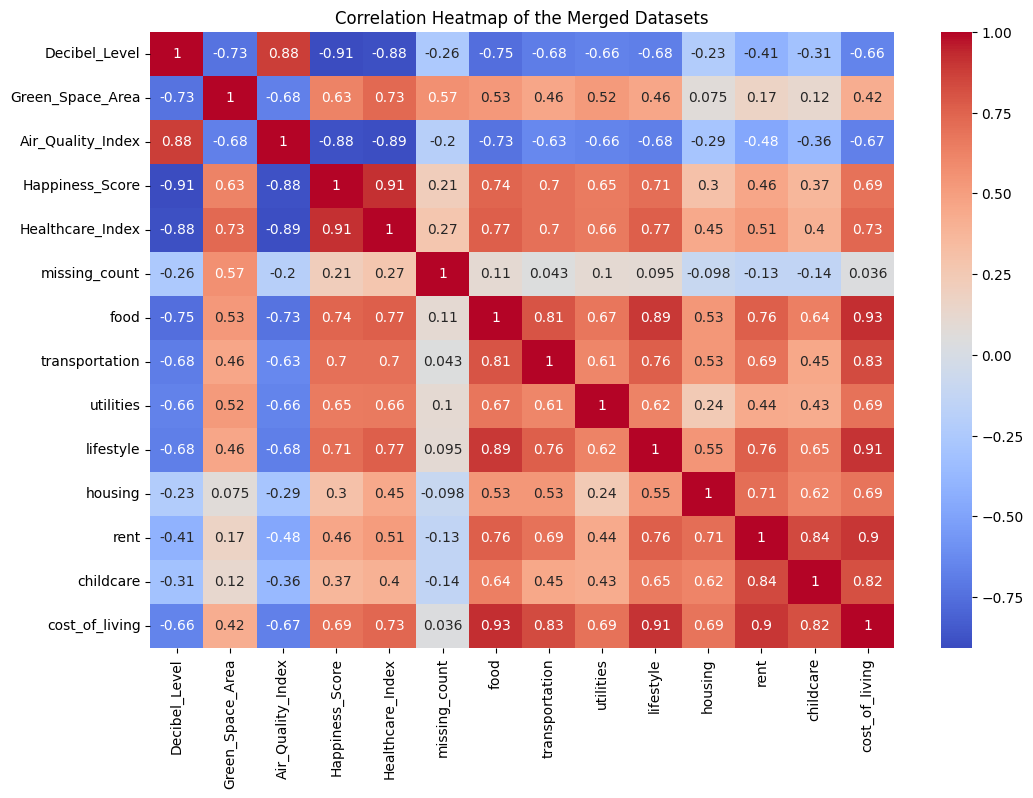

In [26]:
plt.figure(figsize=(12, 8))
sns.heatmap(merged[['Decibel_Level', 'Green_Space_Area', 'Air_Quality_Index', 'Happiness_Score', 'Healthcare_Index', 'missing_count', 'food', 'transportation', 'utilities', 'lifestyle', 'housing', 'rent', 'childcare', 'cost_of_living']].corr(), cmap="coolwarm", annot=True)
plt.title('Correlation Heatmap of the Merged Datasets')

After merging the two datasets, the calculated cost of living index forms a moderate positive correlation with the happiness score, indicating that more expensive cities tend to have higher happiness scores. Although a more expensive city may appear to be a downside, the correlation heatmap suggests that higher-cost cities tend to have higher healthcare index, lower noise levels, and better air quality, which can reflect better infrastructure or development.

Interestingly, there is a strong negative correlation when comparing the `Decibel_Level` and `Air_Quality_Index` features and the cost-of-living categories, especially food, transportation, utilities, and lifestyle. This suggests that the higher-cost cities in the merged dataset tend to have lower noise levels and better air quality; however, this can be counterintuitive because denser cities are typically more expensive and expected to have more noise and air pollution. One possible explanation for this is that the high-cost cities in this dataset may include those better infrastructure and urban planning, which reduces their noise and air pollution.


In [27]:
merged.describe()

,Decibel_Level,Green_Space_Area,Air_Quality_Index,Happiness_Score,Healthcare_Index,missing_count,food,transportation,utilities,lifestyle,housing,rent,childcare,cost_of_living
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,84.000000,87.000000,87.000000,87.000000
mean,65.172414,54.655172,88.735632,6.242529,76.482759,0.287356,18.865499,21.188537,8.521064,17.751019,3.556072,7.110091,13.882378,13.030373
std,11.243817,45.179185,65.924633,1.795319,17.598138,0.847816,7.629278,6.984264,4.819809,5.840786,3.177712,4.858446,9.745945,5.159999
min,50.000000,5.000000,5.000000,2.500000,35.000000,0.000000,4.900940,7.003770,0.744241,5.935545,0.215266,0.751645,0.548571,3.902229
25%,55.000000,25.000000,35.000000,5.000000,62.500000,0.000000,12.029421,15.571985,4.944584,12.866329,1.265895,3.719977,8.017095,8.433435
50%,65.000000,40.000000,70.000000,6.500000,80.000000,0.000000,19.471304,21.605235,8.200293,18.156083,2.293009,6.016895,11.216439,13.707908
75%,75.000000,72.500000,127.500000,7.900000,92.500000,0.000000,24.801680,25.107049,11.419672,22.400379,5.036491,9.422649,17.229471,16.470644
max,90.000000,280.000000,245.000000,8.600000,99.000000,4.000000,37.330602,41.724518,22.560579,30.657343,19.493038,26.547284,55.657656,27.416283


### Bivariate Exploration

In [ ]:
sns.pairplot(merged)
plt.title('Pairplot Between all Numerical Features of the Merged Data')

Text(0.5, 1.0, 'Pairplot Between all Numerical Features of the Merged Data')

The pairplot shows that there is strong multicollinearity among the individual categories of the constructed cost of living index. This suggests that cities expensive in one category are expensive in others. Because of this multicollinearity, it is likely best to use only the constructed cost of living index or only the individual components for statistical analysis or model training.

Additionally, there appears to be multicollinearity among the urban indicators of the first dataset:
* `Decibel_Level` vs `Green_Space_Area` has a strong negative relationship
* `Decibel_Level` vs `Air_Quality_Index` has a strong positive relationship
* `Decibel_Level` vs `Healthcare_Index` has a strong negative relationship
* `Green_Space_Area` vs `Air_Quality_Index` has a negative, but nonlinear, relationship
* `Green_Space_Area` vs `Healthcare_Index` has a negative, but nonlinear, relationship
* `Air_Quality_Index` vs `Healthcare_Index` has a strong negative relationship

There also appears to be some multicollinearity between the urban indicators and cost of living categories, but many of these relationships are weak, noisy, or nonlinear.

In [ ]:
features = ['Decibel_Level', 'Green_Space_Area', 'Air_Quality_Index', 'Healthcare_Index', 'food', 'transportation', 'utilities', 'lifestyle', 'housing', 'rent', 'childcare', 'cost_of_living']

fig, ax = plt.subplots(len(features)//2, 2, figsize=(20, 40))
for idx, col in enumerate(features):
    sns.barplot(data=merged, x='Traffic_Density', y=col, order=['Low', 'Medium', 'High', 'Very High'], ax=ax[idx//2][idx % 2])
fig.suptitle('Average Value of each Feature and Traffic Density', fontsize=30, y=0.893)

The traffic density also appears to be related with some of the other urban indicator features.
* `Decibel_Level`: The decibel level in cities appears to increase as the amount of traffic increases. This is expected as heavy traffic is expected to be noisier.
* `Green_Space_Area`: Cities with more green space tend to have less traffic. This suggests that greener cities may not be as densely packed as other cities.
* `Air_Quality_Index`: The air quality index increases greatly as traffic increases. This is expected as traffic has lots of vehicles, which are associated with air pollution. The error bars are larger in this feature, which means there may be other factors impacting the air quality index, too.
* `Healthcare_Index`: The healthcare index decreases as traffic density increases.

The cost of living generally appears to decrease as traffic density increases. Because these datasets are noisier, the error bars tend to be much larger than the other categories. Rent and childcare costs do not appear to have a linear relationship with traffic density; they peak at medium traffic and decrease elsewhere. There appears to be no clear relationship at all with housing costs; this suggests that housing prices are not well-explained by traffic density.

In [ ]:
features = ['Decibel_Level', 'Green_Space_Area', 'Air_Quality_Index', 'Healthcare_Index', 'food', 'transportation', 'utilities', 'lifestyle', 'housing', 'rent', 'childcare', 'cost_of_living']

fig, ax = plt.subplots(len(features)//2, 2, figsize=(20, 40))
for idx, col in enumerate(features):
    sns.scatterplot(merged, x=col, y='Happiness_Score', ax=ax[idx//2][idx % 2])
plt.title('Scatterplots between Individual Features and the Target')

From the scatterplots, the features show clear relationships with the `Happiness_Score`.
* `Decibel_Level` and `Air_Quality_Index` show strong negative relationships with happiness, so louder cities and cities with worse air quality have lower happiness scores.
* `Healthcare_Index` shows a strong positive relationship with happiness, so cities with better healthcare generally have higher happiness scores.
* `Green_Space_Area` also appears to have a positive relationship with happiness, but the relatiojnship appears nonlinear and has some outliers.
* The constructured cost of living index and category scores also appear to have a positive relationship with happiness, but their distributions are more scattered than that of the other dataset's features.
Overall, the scatterplots reflect the insights gained from the correlation heatmap, showing that happiness is associated with healthcare, noise, air quality, and cost of living.

In [ ]:
sns.barplot(data=merged, x='Traffic_Density', y='Happiness_Score', order=['Low', 'Medium', 'High', 'Very High'])
plt.title('Average Happiness Score by Traffic Density')

This barplot shows that as the `Traffic_Density` gets higher, happiness tends to decrease. This is intuitive; high traffic increases commute time, stress, noise pollution, and air pollution, which reduces overall quality of life.

# 2. Hypothesis Testing
During Milestone 1, we came up with the following initial hypotheses:
* Null Hypothesis (H0): A city’s food, housing, and transportation costs have no significant relationship with its quality of life.
* Alternative Hypothesis (HA): A city’s food, housing, and transportation costs have a significant relationship with its quality of life.

To adjust for our specific features and target, our new hypothesis is as follows:
* Null Hypothesis (H0): A city's decibel level, traffic density, green space area, air quality index, healthcare index, and cost of living have no significant relationship with its happiness score.
* Alternative Hypothesis (HA): A city's decibel level, traffic density, green space area, air quality index, healthcare index, and cost of living have a significant relationship with its happiness score.


In [ ]:
import pandas as pd
from scipy import stats

df = merged.copy()

# Encode traffic density
traffic_map = {'Low' : 1, 'Medium': 2, 'High' : 3, 'Very High' : 4}
df['Traffic_Density_Encoded'] = df['Traffic_Density'].map(traffic_map)

# Define features
test_features = ['Decibel_Level', 'Traffic_Density_Encoded', 'Green_Space_Area', 'Air_Quality_Index', 'Healthcare_Index', 'cost_of_living']

# Hypothesis testing
alpha = 0.05

print("="*60)
print("PEARSON CORRELATION vs HAPPINESS SCORE")
print("="*60)
print(f"{'Feature':<28} {'r':>8} {'P-Value':>10}   Verdict")
print("-"*60)

for col in test_features:
    clean = df[[col, 'Happiness_Score']].dropna()
    r, p = stats.pearsonr(clean[col], clean['Happiness_Score'])
    verdict = "We reject the null hypothesis." if p < alpha else "We fail to reject the null hypothesis."
    print(f"{col:<28} {r:>8.4f} {p:>10.2e}   {verdict}")

print("-"*60)
print(f"\nAlpha: {alpha}")
print("Reject H0 if p-value < 0.05")


### Pearson Correlation Test Evaluation
In our pearson correlation test, we observe each feature individually and obtain a P-value. If that value is below 0.05, we reject the null hypothesis for that feature. What this means for our test specifically is that if the p-value is low, we can say that there *is* a correlation between that feature and our target, the happiness score.

For all six features, we find that the p-value is exceedingly low, suggesting that it is nearly impossible that these features are correlated to happiness score by chance. Using the r-value, we can analyze the strength of a correlation between a feature and the happiness score, with a value of +1 indicating a perfect positive correlation, and a value of -1 indicating a perfect negative correlation.

Looking at each individual feature, the r-values follow intuitively. For decibel level, an r-value of -0.9068 suggests a strong negative correlation with happiness score. Traffic density is much the same, with an r-value of -0.8107. Green space then suggests a moderately strong correlation with happiness score, at an r-value of 0.6274. Air quality index again has a strong negative correlation at -0.8796, and Healthcare index boasts the strong correlation, positive or negative, at 0.9148. The only feature which does not follow intuitive reasoning is cost of living, which sits at an r-value of 0.6896, moderately strong in the positive direction. This, along with the generally high r-values observed, can suggest that a significant amount of multicolinearity is at play, with some of the positively correlated features being highly correlated to the cost of living.

As we observe all six features rejecting the null hypothesis, we can conclusively say that we entirely reject the null hypothesis, and thus, there is a correlation between a city's decibel level, traffic density, green space area, air quality index, healthcare index, cost of living, and its happiness score.


# 3. Model Building

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Features and Target
X = merged[['Decibel_Level', 'Traffic_Density', 'Green_Space_Area', 'Air_Quality_Index', 'Healthcare_Index', 'cost_of_living']]
y = merged['Happiness_Score']

# Preprocess Categorical Column
transformer = ColumnTransformer(
    transformers=[
        ('traffic', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]), ['Traffic_Density'])
    ],
    remainder='passthrough'
)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Transform Data
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R^2:", r2)
print("RMSE:", rmse)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2)

plt.xlabel("Actual Happiness Score")
plt.ylabel("Predicted Happiness Score")
plt.title("Actual vs Predicted Happiness Scores (Linear Regression)")
plt.show()

In [ ]:
# Get feature names after transformation
feature_names = ['Traffic_Density_encoded',
                 'Decibel_Level', 'Green_Space_Area',
                 'Air_Quality_Index', 'Healthcare_Index',
                 'cost_of_living']

coeffs = model.coef_

for name, coef in zip(feature_names, coeffs):
    print(f"{name}: {coef}")

### Model Performance Evaluation
The linear regression coefficients provide insight into how each predictor influences the happiness score while holding all other variables constant. Traffic_Density has the strongest negative effect (–0.467), indicating that cities with heavier traffic tend to have substantially lower happiness levels. Decibel_Level (–0.031) and Air_Quality_Index (–0.003) also show negative relationships, suggesting that noise pollution and poor air quality reduce happiness, though to a lesser degree.

On the positive side, Healthcare_Index has the strongest positive effect (+0.037), meaning that cities with higher-quality healthcare tend to report higher happiness scores. Green_Space_Area has a small positive coefficient (+0.00063), reflecting that additional green space contributes modestly to happiness. Interestingly, cost_of_living shows a slight positive effect (+0.0058), which may indicate that higher-cost cities also offer better services, infrastructure, or amenities that contribute to overall well-being.

Together, these coefficients align with expectations from the EDA and provide interpretable evidence of how environmental and economic factors shape city-level happiness.

# 4. Knowledge Discovery

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

features_to_cluster = ['Happiness_Score', 'cost_of_living', 'Traffic_Density', 'Healthcare_Index']

cluster_data = merged[features_to_cluster].dropna().copy()

for col in cluster_data.select_dtypes(include=['str', 'category']).columns:
    le = LabelEncoder()
    cluster_data[col] = le.fit_transform(cluster_data[col])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_data['Cluster'] = kmeans.fit_predict(scaled_data)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cluster_data,
    x='cost_of_living',
    y='Happiness_Score',
    hue='Cluster',
    palette='viridis',
    alpha=0.7
)
plt.title('Knowledge Discovery: City Clusters (Cost vs. Happiness)')
plt.xlabel('Cost of Living Index')
plt.ylabel('Happiness Score')
plt.show()

cluster_means = cluster_data.groupby('Cluster').mean()
display(cluster_means)

**K-Means Clustering Interpretations**

In this phase of our project, we wanted to transition from just having isolated statistcal correlations to uncovering real world city archetypes that can be gleaned from our dataset. We first began by extracting the features that we felt were more influential which were Happiness Score, Cost of Living, Traffic Density, and Healthcare Index. There were some preprocessing hurdles that we overcame by using label encoding and standard scaling to transform the cateogrical values into a mathematical format suitable for unsupervised learning. We then used K-mean clustering to help interpret the data into four distinct profiles to help distinguish certain archetypes from each other. With this, we were able to have interesting insights regarding our datasets and feature importance.

While it initially seems like financial reasons should be the primary factor of happiness, Traffic Density was the biggest factor for happiness score. We can see that it has the strongest negative coefficient of regression, and it had a strong presence in our lowest tier cluster. Going through each of our clusters we can see that the best one goes to the High Cost/Best Healthcare/Low Traffic cluster while the second best one is the Lower Cost/Medium Healthcare/Low Traffic. We can see that higher cost of living does not guarantee happier people and that it has to be paired with Low Traffic in order for people to truly maximize happiness score.

From this data, our actionable insight is that urban planners and policymakers should to pivot their focus from not only attempting to artificially lower cost of living, but also to maximize the effectiveness and quality of public transportation and reduce the amount of traffic to attempt to maximize happiness score within their city.
